In [55]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df=pd.read_csv("Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


EDA

In [57]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [58]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [59]:
#drop duplicates
df.drop_duplicates()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00


In [60]:
#Drop unwanted columns
cols = ["area_type","availability","society","balcony"]

df=df.drop(cols,axis=1)

In [61]:
#cleaning location columns

# 1. Remove leading and trailing spaces
df["location"]=df["location"].str.strip()
df["location"].value_counts()

#2. Handling nan values in location with top 2nd place --> Sarjapur  Road
df["location"] = df["location"].fillna("Sarjapur  Road")
#3.grouping locations with less than 10 hrs into other category
loc=df["location"].value_counts()
loc_less_than_10=loc[loc<=10]
df["location"]=df["location"].apply(lambda x: "others" if  x in loc_less_than_10 else x)

In [62]:
# cleaning size column
df['size'].unique()

# i)Handling nan values in size col
df['size'] = df['size'].fillna("2 BHK")

# ii) Extract only the BHK number and remove unwanted char
df['size'] = df['size'].apply(lambda x: int(x.split()[0]))
df['size'].unique()

# iii)Renaming to size to BHK
df.rename(columns={"size":"bhk"},inplace=True)

In [63]:

# clean total_sqft column
df['total_sqft'].unique()
def clean_total_sqft(sqft):
    try:
        l = sqft.split('-')
        if len(l)==2:
            return (float(l[0])+float(l[1]))/2
        else:
            return float(l[0])
    except:
        return None
        

df['total_sqft'] = df['total_sqft'].apply(clean_total_sqft)

# handling nan values in total_sqft
df['total_sqft'] = df['total_sqft'].fillna(round(df['total_sqft'].mean()))
df["total_sqft"].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ], shape=(1999,))

In [64]:

#Handling nan values in bath
med=df["bath"].median()
df["bath"]=df["bath"].fillna(med)
df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

In [65]:
#create a new col--> price_per_sqft
#formula:    price_per_sqft=price/total_shift
df["price_per_sqft"]=(df["price"]*100000)/df["total_sqft"]
df



,location,bhk,total_sqft,bath,price,price_per_sqft
0,Electronic City Phase II,2,1056.0,2.0,39.07,3699.810606
1,Chikka Tirupathi,4,2600.0,5.0,120.00,4615.384615
2,Uttarahalli,3,1440.0,2.0,62.00,4305.555556
3,Lingadheeranahalli,3,1521.0,3.0,95.00,6245.890861
4,Kothanur,2,1200.0,2.0,51.00,4250.000000
...,...,...,...,...,...,...
13315,Whitefield,5,3453.0,4.0,231.00,6689.834926
13316,others,4,3600.0,5.0,400.00,11111.111111
13317,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,5258.545136
13318,Padmanabhanagar,4,4689.0,4.0,488.00,10407.336319


In [66]:
#handling outliers in total_sqft
#observation--->>In total_sqft column we have houses less than 300 sqft
#in realtime houses starts with min of 300 sqfts

#formula: total_sqft/bhk>=300 -->it keeps all the realistic total sqft


df=df[df["total_sqft"]/df["bhk"]>=300]

All unrealistic total_sqft less than 300 got removed 

<Axes: xlabel='bhk'>

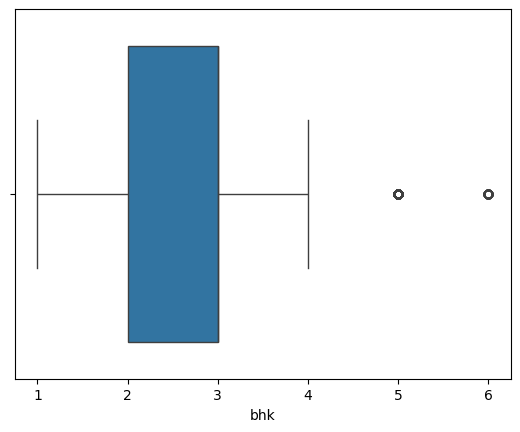

In [67]:
#handling outliers in bhk
df["bhk"].unique()
df=df[df["bhk"]<=6]
sns.boxplot(x="bhk",data=df)

In [68]:
#handling outliers in bath column
df[df["bath"]>df["bhk"]+2][["bhk","bath"]]
#observation: Here no of bath count is suspiciously high compared to bhk number these are outliers

df=df[df["bath"]<df["bhk"]+2]  #removes unrealistic values where no of bath count is suspiciously high compared to bhk number



<Axes: xlabel='price_per_sqft'>

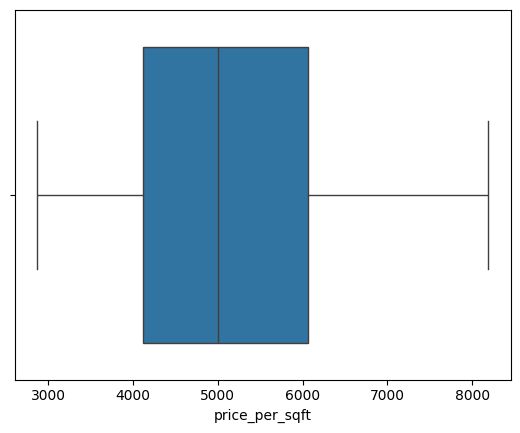

In [69]:
#handling outliers in price_per_sqft


#IQR method

q1=df["price_per_sqft"].quantile(0.25)
q3=df["price_per_sqft"].quantile(0.75)
IQR=q3-q1
lower=q1-0.5*IQR
upper=q3+0.5*IQR
df=df[(df["price_per_sqft"]>=lower)&(df["price_per_sqft"]<=upper)]
sns.boxplot(x="price_per_sqft",data=df)


In [70]:
#drop price_per_sqft
df=df.drop("price_per_sqft",axis=1)

In [71]:
#reset the index
df.reset_index(inplace=True)
df=df.drop("index",axis=1)
df

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
10211,Uttarahalli,3,1345.0,2.0,57.00
10212,Green Glen Layout,3,1715.0,3.0,112.00
10213,Whitefield,5,3453.0,4.0,231.00
10214,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00


<BarContainer object of 241 artists>

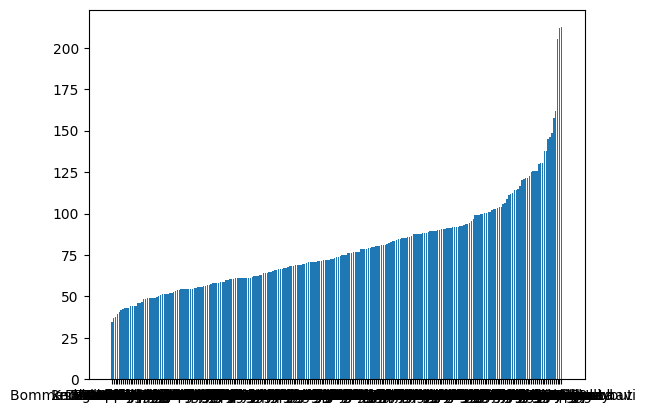

In [72]:
#avg price of location
data=df.groupby("location")["price"].mean().sort_values()
plt.bar(data.index,data)

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor



In [74]:
encoder=LabelEncoder()
df["encoded_loc"]=encoder.fit_transform(df["location"])

In [75]:
#Divide data into input and output
x=df.drop(["location","price"],axis=1) #removing target col
Y=df.price

In [76]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,Y,test_size=0.3,random_state=42)

In [77]:
model=LinearRegression()
model.fit(Xtrain,Ytrain) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
Ypred=model.predict(Xtest)
Ypred

array([67.86750272, 85.83540806, 63.51280032, ..., 55.81072255,
       81.64741523, 72.21422724], shape=(3065,))

In [79]:
print("training efficiency: ",model.score(Xtrain,Ytrain))
print("testing efficiency: ",model.score(Xtest,Ytest))

training efficiency:  0.8670639144582672
testing efficiency:  0.8294296995597875


It is Generalized Model

In [87]:
DT = DecisionTreeRegressor()
DT.fit(Xtrain,Ytrain)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [88]:
ypred = DT.predict(Xtest)
ypred

array([59.01      , 90.33333333, 75.20066667, ..., 52.        ,
       85.46153846, 90.        ], shape=(3065,))

In [90]:
print("Training Eff: ",DT.score(Xtrain,Ytrain))
print("Testing Eff: ",DT.score(Xtest,Ytest))
print("R2: ",r2_score(Ytest,ypred))
print("MAE: ",mean_absolute_error(Ytest,ypred))

Training Eff:  0.9903480245145241
Testing Eff:  0.7545515848021181
R2:  0.7545515848021181
MAE:  14.454132306238261


Decision Tree is Overfitting 

In [80]:
#Model Serialization--->Saving the training model
#req:it skips the continous 

import pickle
with open("Linear_model.pkl","wb") as file:
    pickle.dump(model,file)

In [81]:
#Encoder serialization
import pickle
with open("label_encoder.pkl","wb") as file1:
    pickle.dump(encoder,file1)

In [82]:
#save the file
df.to_csv("cleaned_data.csv")